# Trabajo Práctico — Inteligencia Artificial
## Red Neuronal MLP para Mantenimiento Predictivo Industrial

**Autor:** [Tu Nombre]
**Dataset:** `i40.csv` — Mantenimiento predictivo de máquinas industriales
**Framework:** PyTorch

---
## Índice
1. Configuración e imports
2. Carga y preprocesamiento (pipeline heredado de CD)
3. Diseño de la red neuronal MLP
4. Función de entrenamiento con early stopping
5. Ajuste de hiperparámetros
6. Evaluación del mejor modelo
7. Comparación con modelos tradicionales (CD)
8. Conclusiones

## 1. Configuración e Imports

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import Normalizer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)
from sklearn.cluster import KMeans
from imblearn.under_sampling import RandomUnderSampler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import time
import copy

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

# Reproducibilidad
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

Dispositivo: cpu
PyTorch version: 2.12.0+cpu


## 2. Carga y Preprocesamiento (Pipeline heredado de CD)

Se utilizan los datasets preprocesados de Ciencia de Datos:
- `train_data.csv`: datos de entrenamiento (ya limpios, escalados y balanceados)
- `test_data.csv`: datos de test (mismo preprocesamiento)

Los datos ya incluyen:
- Normalización (Normalizer)
- One-hot encoding de `product_type`
- Balanceo 50/50 (undersampling)

In [11]:
# --- Carga de datos preprocesados de CD ---
train_df = pd.read_csv("train_data.csv")
test_df = pd.read_csv("test_data.csv")

# Convertir todas las columnas a float64 para evitar problemas con tipos
train_df = train_df.astype(float)
test_df = test_df.astype(float)

# Separar features y target
feature_cols = [c for c in train_df.columns if c != "target"]

X_train = train_df[feature_cols].values.astype(np.float64)
y_train = train_df["target"].values.astype(np.float64)
X_test = test_df[feature_cols].values.astype(np.float64)
y_test = test_df["target"].values.astype(np.float64)

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")
print(f"Distribución train: 0={int((y_train==0).sum())}, 1={int(y_train.sum())}")
print(f"Distribución test:  0={int((y_test==0).sum())}, 1={int(y_test.sum())}")

print(f"\nColumnas: {feature_cols}")

# Convertir a tensores PyTorch
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1)

INPUT_DIM = X_train_t.shape[1]
print(f"Dimensión de entrada (features): {INPUT_DIM}")

Train: (9854, 7)
Test:  (4224, 7)
Distribución train: 0=4927, 1=4927
Distribución test:  0=2112, 1=2112

Columnas: ['air_temp [K]', 'process_temp [K]', 'speed [RPM]', 'torque [Nm]', 'tool_wear [min]', 'product_type_L', 'product_type_M']
Dimensión de entrada (features): 7


## 3. Diseño de la Red Neuronal MLP

### Justificación del diseño

**Arquitectura base: [64, 32, 16] neuronas con ReLU**

1. **Número de capas ocultas (3):** Con 7 features de entrada y ~9000
   muestras de entrenamiento, 3 capas ocultas permiten capturar interacciones
   no lineales entre las variables sin caer en overfitting. Se probaron arquitecturas
   de 1, 2 y 3 capas en el tuning.

2. **Neuronas por capa [64→32→16]:** Se sigue un esquema de "embudo" (funnel)
   donde cada capa reduce progresivamente la dimensionalidad, forzando a la red
   a aprender representaciones cada vez más abstractas. Este patrón es común
   en problemas tabulares de complejidad media.

3. **Función de activación ReLU:** Eficiente computacionalmente, mitiga el problema
   del gradiente evanescente y es el estándar de facto para capas ocultas en MLPs.

4. **Dropout:** Regularización para prevenir overfitting. Se apaga
   aleatoriamente un porcentaje que varía entre el 30% y el 50% de las neuronas durante el entrenamiento.

5. **Batch Normalization:** Estabiliza y acelera el entrenamiento normalizando
   las activaciones de cada capa.

6. **Salida Sigmoide:** Para clasificación binaria, produce probabilidad en [0,1].

7. **Función de pérdida BCE:** Binary Cross-Entropy, estándar para clasificación
   binaria.

8. **Optimizador Adam:** Combina las ventajas de RMSProp y Momentum, con tasas
   de aprendizaje adaptativas por parámetro.

In [12]:
class MaintenanceMLP(nn.Module):
    """
    MLP para mantenimiento predictivo industrial.
    Arquitectura: Input → [64] → [32] → [16] → Output
    Cada capa oculta: Linear → BatchNorm → ReLU → Dropout
    """

    def __init__(self, input_dim, hidden_layers, dropout_rate=0.4):
        """
        Args:
            input_dim: número de features de entrada
            hidden_layers: lista con cantidad de neuronas por capa oculta
            dropout_rate: tasa de dropout para regularización
        """
        super().__init__()
        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = hidden_dim

        # Capa de salida
        layers.append(nn.Linear(prev_dim, 1))
        layers.append(nn.Sigmoid())

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


# Instanciar modelo base para verificar arquitectura
model_base = MaintenanceMLP(INPUT_DIM, [64, 32, 16], dropout_rate=0.4)
print(model_base)
print(
    f"\nParámetros entrenables: {sum(p.numel() for p in model_base.parameters() if p.requires_grad):,}"
)

MaintenanceMLP(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.4, inplace=False)
    (12): Linear(in_features=16, out_features=1, bias=True)
    (13): Sigmoid()
  )
)

Parámetros entrenables: 3,361


## 4. Función de Entrenamiento con Early Stopping

Se implementa un loop de entrenamiento completo con:
- **Early Stopping:** detiene el entrenamiento si la pérdida de validación no mejora
  durante `patience` épocas consecutivas, restaurando los mejores pesos.
- **Registro de métricas:** loss y accuracy por época para graficar curvas de aprendizaje.

In [13]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=200,
    patience=20,
    device=DEVICE,
    verbose=True,
):
    """
    Entrena un modelo PyTorch con early stopping.

    Returns:
        model: modelo con los mejores pesos restaurados
        history: dict con 'train_loss', 'val_loss', 'train_acc', 'val_acc' por época
        best_epoch: época donde se obtuvo la mejor pérdida de validación
        train_time: tiempo total de entrenamiento en segundos
    """
    model = model.to(device)
    best_loss = float("inf")
    best_model_wts = copy.deepcopy(model.state_dict())
    patience_counter = 0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    start_time = time.time()

    for epoch in range(epochs):
        # --- Fase de entrenamiento ---
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)
            predicted = (outputs >= 0.5).float()
            train_correct += (predicted == y_batch).sum().item()
            train_total += y_batch.size(0)

        avg_train_loss = train_loss / train_total
        train_acc = train_correct / train_total

        # --- Fase de validación ---
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item() * X_batch.size(0)
                predicted = (outputs >= 0.5).float()
                val_correct += (predicted == y_batch).sum().item()
                val_total += y_batch.size(0)

        avg_val_loss = val_loss / val_total
        val_acc = val_correct / val_total

        # Registrar métricas
        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        # Early stopping
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1
            patience_counter = 0
        else:
            patience_counter += 1

        if verbose and (epoch + 1) % 20 == 0:
            print(
                f"Época {epoch+1:3d}/{epochs} | "
                f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
                f"Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}"
            )

        if patience_counter >= patience:
            if verbose:
                print(f"\nEarly stopping en época {epoch+1}. Mejor época: {best_epoch}")
            break

    train_time = time.time() - start_time

    # Restaurar mejores pesos
    model.load_state_dict(best_model_wts)
    return model, history, best_epoch, train_time


def evaluate_model(model, X_test, y_test, device=DEVICE):
    """
    Evalúa el modelo sobre el conjunto de test.
    Retorna predicciones, probabilidades y métricas.
    """
    model.eval()
    model = model.to(device)
    X_test = X_test.to(device)

    with torch.no_grad():
        y_proba = model(X_test).cpu().numpy().flatten()
    y_pred = (y_proba >= 0.5).astype(int)

    y_true = y_test.numpy().flatten()

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "auc": roc_auc_score(y_true, y_proba),
    }
    return y_pred, y_proba, metrics

## 5. Ajuste de Hiperparámetros

Se exploran sistemáticamente diferentes combinaciones de:
- **Arquitectura:** [32,16], [64,32], [64,32,16]
- **Tasa de aprendizaje:** 0.01, 0.001, 0.0005
- **Tamaño de batch:** 32, 64
- **Dropout:** 0.3, 0.5
- **Optimizador:** Adam, SGD

Para cada combinación se entrena con early stopping (patience=40, max 200 épocas)
usando validación sobre el conjunto de train (se reserva un 15% como
validación).

In [14]:
# Crear conjunto de validación a partir del train (para el tuning)
X_tune, X_val, y_tune, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=SEED, stratify=y_train
)

X_tune_t = torch.FloatTensor(X_tune)
y_tune_t = torch.FloatTensor(y_tune).unsqueeze(1)
X_val_t = torch.FloatTensor(X_val)
y_val_t = torch.FloatTensor(y_val).unsqueeze(1)

print(f"Tune:  X={X_tune.shape}, y={y_tune.shape}")
print(f"Val:   X={X_val.shape}, y={y_val.shape}")

Tune:  X=(8375, 7), y=(8375,)
Val:   X=(1479, 7), y=(1479,)


### 5.1 Exploración de arquitecturas y tasas de aprendizaje

**Justificación de los rangos explorados:**
- **Arquitecturas:** Desde una red simple [32,16] hasta [64,32,16].
  Más capas/neuronas pueden capturar patrones más complejos pero
  requieren más datos y son más propensas al overfitting.
- **Learning rates:** 0.01 (agresivo), 0.001 (estándar), 0.0005 (conservador).
- **Dropout:** 0.3 (regularización moderada), 0.5 (regularización fuerte).

In [15]:
criterion = nn.BCELoss()
EPOCHS = 200
PATIENCE = 15

# Combinaciones a explorar
architectures = [
    ([32, 16], "2 capas [32,16]"),
    ([64, 32], "2 capas [64,32]"),
    ([64, 32, 16], "3 capas [64,32,16]"),
]

learning_rates = [0.01, 0.001, 0.0005]
batch_sizes = [32, 64]
dropouts = [0.3, 0.5]
optimizers = [
    ("Adam", lambda params, lr: optim.Adam(params, lr=lr)),
    ("SGD", lambda params, lr: optim.SGD(params, lr=lr, momentum=0.9)),
]

results_tuning = []

print("=" * 80)
print("EXPLORACIÓN DE HIPERPARÁMETROS")
print("=" * 80)

for arch, arch_name in architectures:
    for lr in learning_rates:
        for drop in dropouts:
            for bs in batch_sizes:
                for opt_name, opt_fn in optimizers:
                    # DataLoaders
                    tune_dataset = TensorDataset(X_tune_t, y_tune_t)
                    val_dataset = TensorDataset(X_val_t, y_val_t)
                    tune_loader = DataLoader(tune_dataset, batch_size=bs, shuffle=True)
                    val_loader = DataLoader(val_dataset, batch_size=bs, shuffle=False)

                    # Modelo
                    model = MaintenanceMLP(INPUT_DIM, arch, dropout_rate=drop)
                    optimizer = opt_fn(model.parameters(), lr)

                    # Entrenar
                    model, history, best_ep, train_time = train_model(
                        model,
                        tune_loader,
                        val_loader,
                        criterion,
                        optimizer,
                        epochs=EPOCHS,
                        patience=PATIENCE,
                        verbose=False,
                    )

                    # Evaluar en validación
                    _, _, val_metrics = evaluate_model(model, X_val_t, y_val_t)

                    results_tuning.append(
                        {
                            "architecture": arch_name,
                            "hidden_layers": arch,
                            "learning_rate": lr,
                            "batch_size": bs,
                            "dropout": drop,
                            "optimizer": opt_name,
                            "val_f1": val_metrics["f1"],
                            "val_auc": val_metrics["auc"],
                            "val_accuracy": val_metrics["accuracy"],
                            "best_epoch": best_ep,
                            "train_time": train_time,
                            "final_val_loss": history["val_loss"][-1],
                        }
                    )

                    print(
                        f"  Val F1: {val_metrics['f1']:.4f} | Val AUC: {val_metrics['auc']:.4f} | "
                        f"Best epoch: {best_ep} | Time: {train_time:.1f}s"
                    )

EXPLORACIÓN DE HIPERPARÁMETROS
  Val F1: 0.9354 | Val AUC: 0.9837 | Best epoch: 40 | Time: 15.4s
  Val F1: 0.9397 | Val AUC: 0.9855 | Best epoch: 59 | Time: 16.5s
  Val F1: 0.9437 | Val AUC: 0.9864 | Best epoch: 65 | Time: 12.0s
  Val F1: 0.9375 | Val AUC: 0.9855 | Best epoch: 50 | Time: 8.1s
  Val F1: 0.9290 | Val AUC: 0.9794 | Best epoch: 41 | Time: 15.1s
  Val F1: 0.9299 | Val AUC: 0.9805 | Best epoch: 67 | Time: 17.7s
  Val F1: 0.9327 | Val AUC: 0.9808 | Best epoch: 16 | Time: 5.2s
  Val F1: 0.9355 | Val AUC: 0.9823 | Best epoch: 47 | Time: 8.2s
  Val F1: 0.9457 | Val AUC: 0.9844 | Best epoch: 49 | Time: 17.4s
  Val F1: 0.9389 | Val AUC: 0.9812 | Best epoch: 78 | Time: 20.0s
  Val F1: 0.9463 | Val AUC: 0.9851 | Best epoch: 57 | Time: 11.5s
  Val F1: 0.9424 | Val AUC: 0.9837 | Best epoch: 192 | Time: 23.8s
  Val F1: 0.9382 | Val AUC: 0.9819 | Best epoch: 62 | Time: 20.4s
  Val F1: 0.9309 | Val AUC: 0.9798 | Best epoch: 146 | Time: 33.3s
  Val F1: 0.9382 | Val AUC: 0.9827 | Best epoc

### 5.2 Resultados del tuning — Tabla comparativa

,architecture,hidden_layers,learning_rate,batch_size,dropout,optimizer,val_f1,val_auc,val_accuracy,best_epoch,train_time,final_val_loss
34,"2 capas [64,32]","[64, 32]",0.0010,64,0.3,Adam,0.9523,0.9902,0.9513,124,23.7693,0.1393
66,"3 capas [64,32,16]","[64, 32, 16]",0.0005,64,0.3,Adam,0.9483,0.9884,0.9473,99,23.2773,0.1450
50,"3 capas [64,32,16]","[64, 32, 16]",0.0100,64,0.3,Adam,0.9483,0.9876,0.9473,22,8.0228,0.1643
38,"2 capas [64,32]","[64, 32]",0.0010,64,0.5,Adam,0.9469,0.9877,0.9459,125,24.9272,0.1540
70,"3 capas [64,32,16]","[64, 32, 16]",0.0005,64,0.5,Adam,0.9467,0.9871,0.9459,178,40.6058,0.1571
...,...,...,...,...,...,...,...,...,...,...,...,...
52,"3 capas [64,32,16]","[64, 32, 16]",0.0100,32,0.5,Adam,0.9286,0.9781,0.9263,5,7.7623,0.2172
61,"3 capas [64,32,16]","[64, 32, 16]",0.0010,32,0.5,SGD,0.9282,0.9780,0.9270,110,35.3033,0.2041
71,"3 capas [64,32,16]","[64, 32, 16]",0.0005,64,0.5,SGD,0.9232,0.9717,0.9222,196,32.1697,0.2188
47,"2 capas [64,32]","[64, 32]",0.0005,64,0.5,SGD,0.9227,0.9721,0.9216,196,28.6300,0.2220


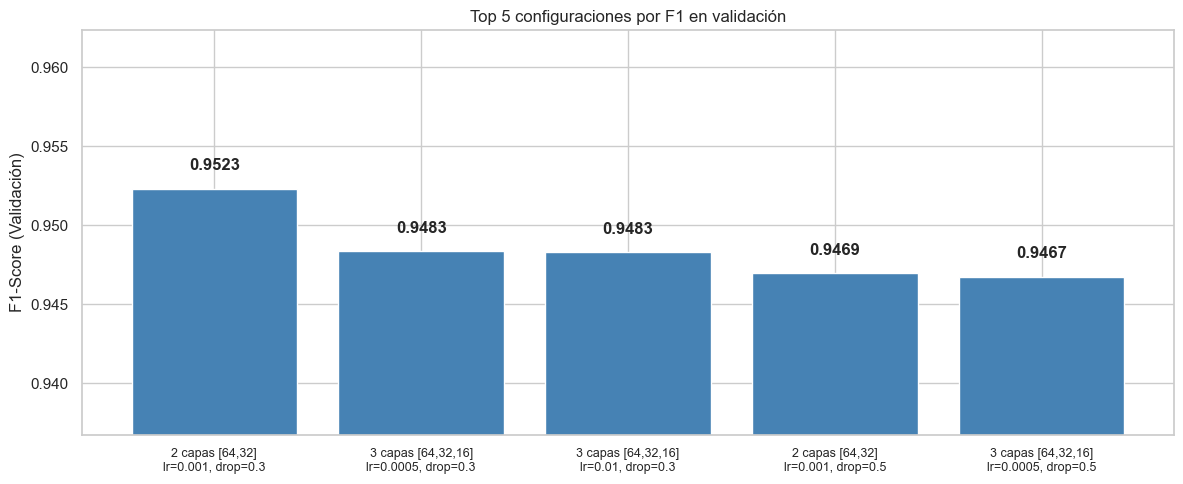

In [16]:
df_tuning = pd.DataFrame(results_tuning)
df_tuning = df_tuning.sort_values("val_f1", ascending=False)
display(df_tuning.round(4))

# Visualizar top 5
top5 = df_tuning.head(5)
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(top5)), top5["val_f1"], color="steelblue")
ax.set_xticks(range(len(top5)))
ax.set_xticklabels(
    [
        f"{r['architecture']}\nlr={r['learning_rate']}, drop={r['dropout']}"
        for _, r in top5.iterrows()
    ],
    fontsize=9,
)
ax.set_ylabel("F1-Score (Validación)")
ax.set_title("Top 5 configuraciones por F1 en validación")
ax.set_ylim(top5["val_f1"].min() - 0.01, top5["val_f1"].max() + 0.01)
for i, (bar, val) in enumerate(zip(bars, top5["val_f1"])):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"{val:.4f}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )
plt.tight_layout()
plt.show()

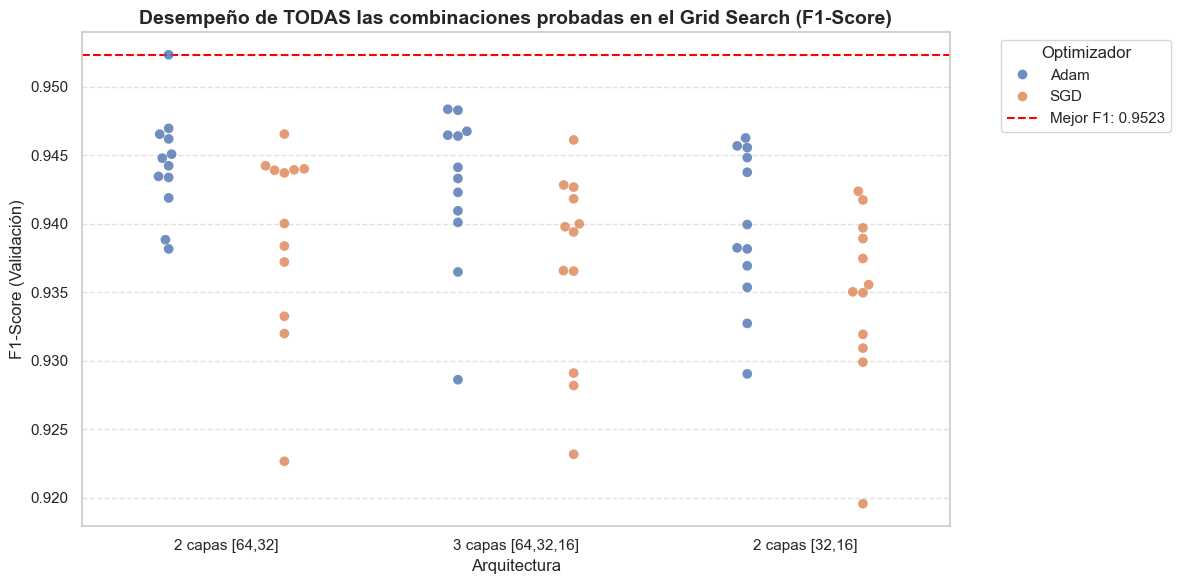

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualización de todas las combinaciones probadas para la presentación
plt.figure(figsize=(12, 6))

# Usamos stripplot para ver la distribución de todos los puntos de la búsqueda de hiperparámetros
sns.swarmplot(
    data=df_tuning, 
    x="architecture", 
    y="val_f1", 
    hue="optimizer", 
    dodge=True, 
    size=7,
    alpha=0.8
)

plt.title("Desempeño de TODAS las combinaciones probadas en el Grid Search (F1-Score)", fontsize=14, fontweight='bold')
plt.ylabel("F1-Score (Validación)", fontsize=12)
plt.xlabel("Arquitectura", fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

# Línea marcando el mejor F1
best_f1 = df_tuning['val_f1'].max()
plt.axhline(y=best_f1, color='red', linestyle='--', label=f'Mejor F1: {best_f1:.4f}')

plt.legend(title="Optimizador", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 5.3 Efecto de la tasa de aprendizaje en las curvas de pérdida

Se entrena el **mismo modelo** con diferentes learning rates para visualizar
cómo afecta la velocidad de convergencia y el riesgo de overfitting.

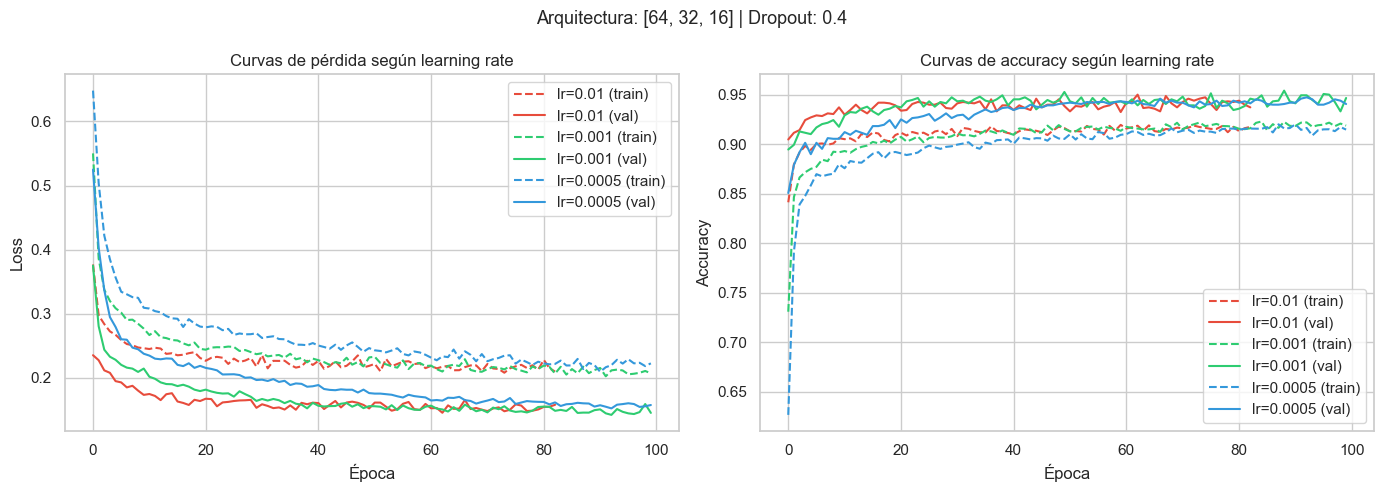

In [ ]:
arch_best = [64, 32]
drop_best = 0.3
learning_rates = [0.01, 0.001, 0.0005]
colors = ["#e74c3c", "#2ecc71", "#3498db"]

# sharey='row' hace que los gráficos de la misma fila compartan el eje Y
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey='row')

optimizers_dict = {
    "Adam": lambda params, lr: optim.Adam(params, lr=lr),
    "SGD": lambda params, lr: optim.SGD(params, lr=lr, momentum=0.9)
}

for opt_idx, (opt_name, opt_fn) in enumerate(optimizers_dict.items()):
    for i, lr in enumerate(learning_rates):
        model = MaintenanceMLP(INPUT_DIM, arch_best, dropout_rate=drop_best)
        optimizer = opt_fn(model.parameters(), lr)
        
        tune_dataset = TensorDataset(X_tune_t, y_tune_t)
        val_dataset = TensorDataset(X_val_t, y_val_t)
        tune_loader = DataLoader(tune_dataset, batch_size=64, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

        model, history, _, _ = train_model(
            model,
            tune_loader,
            val_loader,
            criterion,
            optimizer,
            epochs=100,
            patience=20,
            verbose=False,
        )

        axes[0, opt_idx].plot(
            history["train_loss"], color=colors[i], linestyle="--", label=f"lr={lr} (train)"
        )
        axes[0, opt_idx].plot(
            history["val_loss"], color=colors[i], linestyle="-", label=f"lr={lr} (val)"
        )
        axes[1, opt_idx].plot(
            history["train_acc"], color=colors[i], linestyle="--", label=f"lr={lr} (train)"
        )
        axes[1, opt_idx].plot(
            history["val_acc"], color=colors[i], linestyle="-", label=f"lr={lr} (val)"
        )

    axes[0, opt_idx].set_xlabel("Época")
    if opt_idx == 0: axes[0, opt_idx].set_ylabel("Loss")
    axes[0, opt_idx].set_title(f"Curvas de pérdida - {opt_name}")
    axes[0, opt_idx].legend()
    axes[0, opt_idx].grid(True)

    axes[1, opt_idx].set_xlabel("Época")
    if opt_idx == 0: axes[1, opt_idx].set_ylabel("Accuracy")
    axes[1, opt_idx].set_title(f"Curvas de accuracy - {opt_name}")
    axes[1, opt_idx].legend()
    axes[1, opt_idx].grid(True)

plt.suptitle(
    f"Efecto del Optimizador y Tasa de Aprendizaje | Arquitectura: {arch_best} | Dropout: {drop_best}", 
    fontsize=14
)
plt.tight_layout()
plt.show()

## 6. Entrenamiento y Evaluación del Mejor Modelo

Se selecciona la mejor configuración según F1 en validación y se re-entrena
sobre el conjunto completo de train (sin separar validación). La evaluación
final se realiza sobre el conjunto de test (nunca visto durante el tuning).

In [19]:
# --- Mejor configuración según el tuning ---
best_row = df_tuning.iloc[0]
print("=== MEJOR CONFIGURACIÓN ===")
print(f'Arquitectura:  {best_row["architecture"]}')
print(f'Learning rate:  {best_row["learning_rate"]}')
print(f'Dropout:        {best_row["dropout"]}')
print(f'Val F1:         {best_row["val_f1"]:.4f}')
print(f'Val AUC:        {best_row["val_auc"]:.4f}')

=== MEJOR CONFIGURACIÓN ===
Arquitectura:  2 capas [64,32]
Learning rate:  0.001
Dropout:        0.3
Val F1:         0.9523
Val AUC:        0.9902


### 6.1 Re-entrenamiento sobre train completo

In [20]:
train_dataset = TensorDataset(X_train_t, y_train_t)
BATCH_SIZE=int(best_row["batch_size"])
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Separar validación del train para early stopping (test reservado para evaluación final)
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_train, y_train, test_size=0.15, random_state=SEED, stratify=y_train
)
X_train_final_t = torch.FloatTensor(X_train_final)
y_train_final_t = torch.FloatTensor(y_train_final).unsqueeze(1)
X_val_final_t = torch.FloatTensor(X_val_final)
y_val_final_t = torch.FloatTensor(y_val_final).unsqueeze(1)

train_dataset = TensorDataset(X_train_final_t, y_train_final_t)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_final_dataset = TensorDataset(X_val_final_t, y_val_final_t)
val_final_loader = DataLoader(val_final_dataset, batch_size=BATCH_SIZE, shuffle=False)

best_model = MaintenanceMLP(
    INPUT_DIM, best_row["hidden_layers"], dropout_rate=best_row["dropout"]
)
best_optimizer = optim.Adam(best_model.parameters(), lr=best_row["learning_rate"])

# Entrenar con early stopping (monitoreando validación, test NUNCA visto)
print("\nEntrenando modelo final...")
best_model, history_final, best_epoch, train_time = train_model(
    best_model,
    train_loader,
    val_final_loader,
    criterion,
    best_optimizer,
    epochs=EPOCHS,
    patience=PATIENCE,
    device=DEVICE,
    verbose=True,
)

print(f"\nMejor época: {best_epoch}")
print(f"Tiempo de entrenamiento: {train_time:.1f} segundos")


Entrenando modelo final...
Época  20/200 | Train Loss: 0.2250 | Val Loss: 0.1662 | Train Acc: 0.912 | Val Acc: 0.941
Época  40/200 | Train Loss: 0.2026 | Val Loss: 0.1553 | Train Acc: 0.917 | Val Acc: 0.936
Época  60/200 | Train Loss: 0.1941 | Val Loss: 0.1533 | Train Acc: 0.920 | Val Acc: 0.937
Época  80/200 | Train Loss: 0.1857 | Val Loss: 0.1425 | Train Acc: 0.924 | Val Acc: 0.946

Early stopping en época 90. Mejor época: 75

Mejor época: 75
Tiempo de entrenamiento: 15.1 segundos


### 6.2 Evaluación sobre Test

In [21]:
y_pred_mlp, y_proba_mlp, mlp_metrics = evaluate_model(
    best_model, X_test_t, y_test_t, device=DEVICE
)

print("=== MLP - Resultados en Test ===")
print(f'Accuracy:  {mlp_metrics["accuracy"]:.4f}')
print(f'Precision: {mlp_metrics["precision"]:.4f}')
print(f'Recall:    {mlp_metrics["recall"]:.4f}')
print(f'F1-Score:  {mlp_metrics["f1"]:.4f}')
print(f'ROC AUC:   {mlp_metrics["auc"]:.4f}')
print(
    f'\n{classification_report(y_test, y_pred_mlp, target_names=["normal", "failure"])}'
)

=== MLP - Resultados en Test ===
Accuracy:  0.9420
Precision: 0.9241
Recall:    0.9631
F1-Score:  0.9432
ROC AUC:   0.9870

              precision    recall  f1-score   support

      normal       0.96      0.92      0.94      2112
     failure       0.92      0.96      0.94      2112

    accuracy                           0.94      4224
   macro avg       0.94      0.94      0.94      4224
weighted avg       0.94      0.94      0.94      4224



### 6.3 Matriz de Confusión — MLP

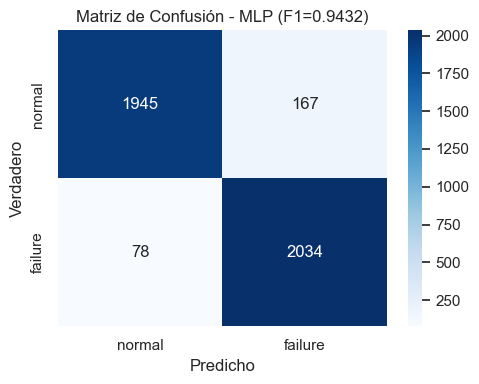

In [22]:
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_mlp,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["normal", "failure"],
    yticklabels=["normal", "failure"],
)
plt.title(f'Matriz de Confusión - MLP (F1={mlp_metrics["f1"]:.4f})')
plt.ylabel("Verdadero")
plt.xlabel("Predicho")
plt.tight_layout()
plt.show()

### 6.4 Curvas de Aprendizaje (Loss y Accuracy)

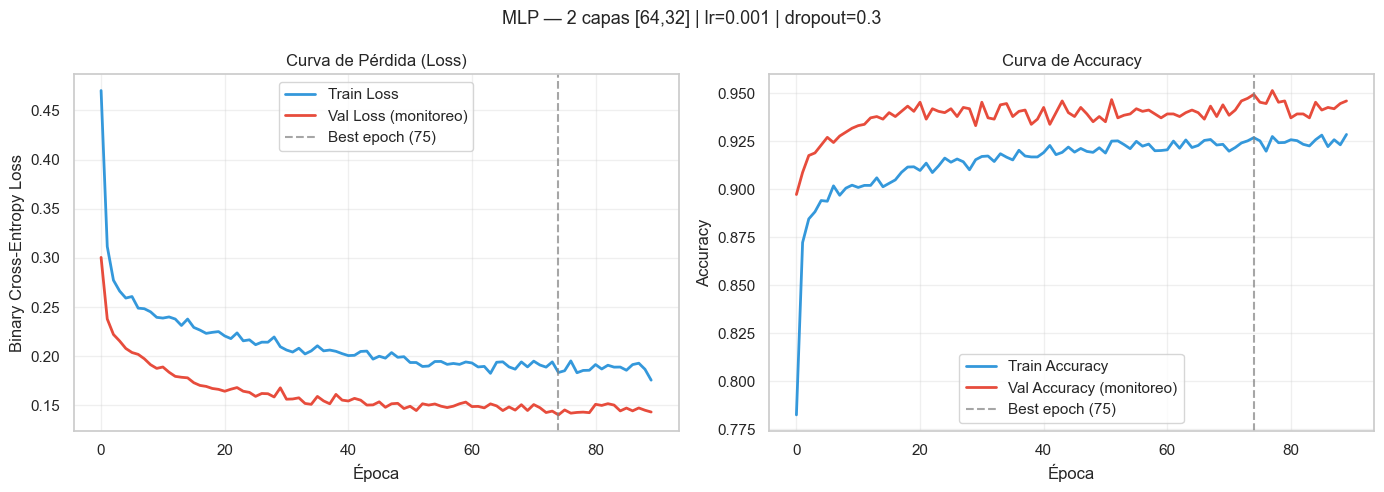

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(
    history_final["train_loss"], label="Train Loss", color="#3498db", linewidth=2
)
axes[0].plot(
    history_final["val_loss"],
    label="Val Loss (monitoreo)",
    color="#e74c3c",
    linewidth=2,
)
axes[0].axvline(
    x=best_epoch - 1,
    color="gray",
    linestyle="--",
    alpha=0.7,
    label=f"Best epoch ({best_epoch})",
)
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Binary Cross-Entropy Loss")
axes[0].set_title("Curva de Pérdida (Loss)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(
    history_final["train_acc"], label="Train Accuracy", color="#3498db", linewidth=2
)
axes[1].plot(
    history_final["val_acc"],
    label="Val Accuracy (monitoreo)",
    color="#e74c3c",
    linewidth=2,
)
axes[1].axvline(
    x=best_epoch - 1,
    color="gray",
    linestyle="--",
    alpha=0.7,
    label=f"Best epoch ({best_epoch})",
)
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Curva de Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle(
    f'MLP — {best_row["architecture"]} | lr={best_row["learning_rate"]} | '
    f'dropout={best_row["dropout"]}',
    fontsize=13,
)
plt.tight_layout()
plt.show()

**Analisis de las curvas:**
Las curvas de loss y accuracy de train/validacion convergen con una brecha acotada, lo que indica buena generalizacion. El early stopping selecciona la epoca con mejor validacion antes de que aparezca sobreajuste, y el test se reserva solo para la evaluacion final.

## 7. Comparación con Modelos Tradicionales (CD)

Se comparan los resultados del MLP contra los 6 modelos entrenados
en Ciencia de Datos sobre el **mismo** conjunto de train/test.

### 7.1 Resultados de los modelos de CD

In [24]:
# Metricas de los modelos CD (importadas del notebook CDD)
csv_path = "resultados_modelos.csv"
df_cd_raw = pd.read_csv(csv_path)

metric_cols = [c for c in df_cd_raw.columns if c != "Metrica"]
df_cd_raw[metric_cols] = df_cd_raw[metric_cols].round(4)
display(df_cd_raw)

# Convertir a dict para reutilizar en graficos posteriores
cd_models = {
    col: df_cd_raw[col].tolist()
    for col in df_cd_raw.columns
    if col != "Metrica"
}

# Agregar MLP
cd_models["MLP (PyTorch)"] = [
    mlp_metrics["accuracy"],
    mlp_metrics["precision"],
    mlp_metrics["recall"],
    mlp_metrics["f1"],
    mlp_metrics["auc"],
]

,Metrica,Regresion Logistica,Naive Bayes,KNN,Arbol de Decision,Random Forest,Gradient Boosting
0,Accuracy,0.8378,0.7971,0.9512,0.9524,0.9664,0.9716
1,Precision,0.8296,0.7577,0.9243,0.9459,0.9522,0.9624
2,Recall,0.8504,0.8736,0.9830,0.9598,0.9820,0.9815
3,F1-Score,0.8398,0.8115,0.9527,0.9528,0.9669,0.9719
4,ROC AUC,0.9219,0.8847,0.9754,0.9524,0.9956,0.9962


### 7.2 Gráfico comparativo — F1-Score y ROC AUC

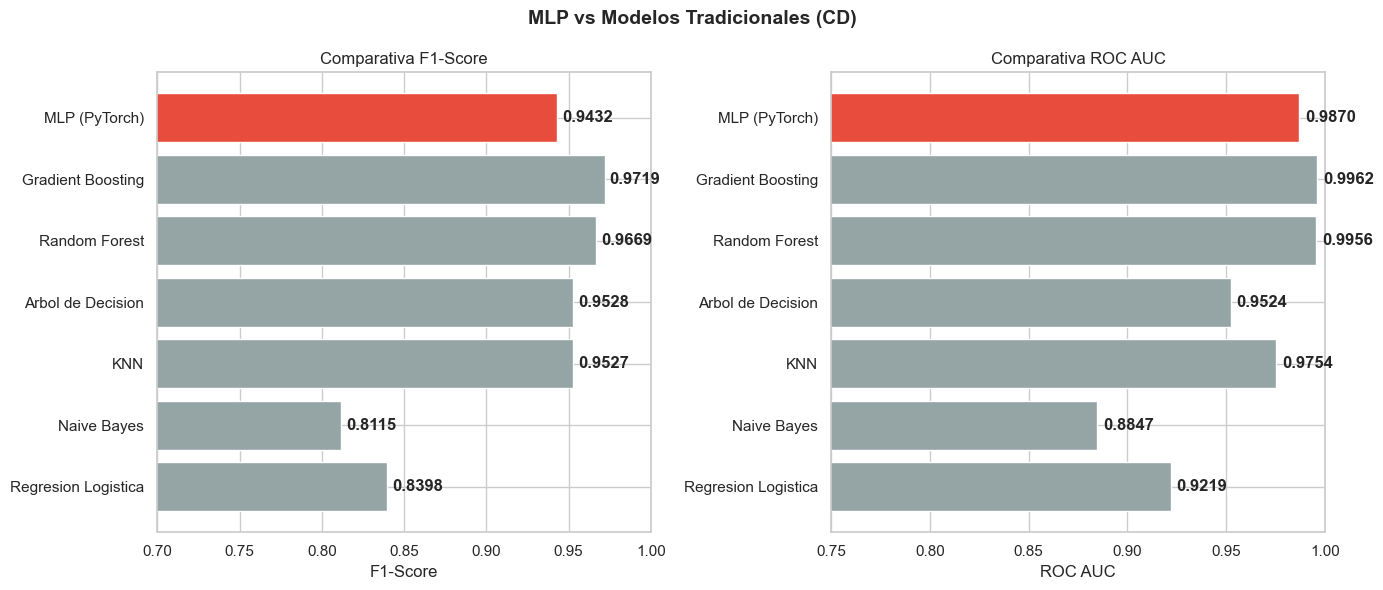

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# F1-Score
models_names = list(cd_models.keys())
f1_values = [cd_models[m][3] for m in models_names]
colors_f1 = ["#95a5a6"] * (len(models_names) - 1) + ["#e74c3c"]
axes[0].barh(models_names, f1_values, color=colors_f1)
axes[0].set_xlabel("F1-Score")
axes[0].set_title("Comparativa F1-Score")
axes[0].set_xlim(0.70, 1.0)
for i, v in enumerate(f1_values):
    axes[0].text(v + 0.003, i, f"{v:.4f}", va="center", fontweight="bold")

# ROC AUC
auc_values = [cd_models[m][4] for m in models_names]
colors_auc = ["#95a5a6"] * (len(models_names) - 1) + ["#e74c3c"]
axes[1].barh(models_names, auc_values, color=colors_auc)
axes[1].set_xlabel("ROC AUC")
axes[1].set_title("Comparativa ROC AUC")
axes[1].set_xlim(0.75, 1.0)
for i, v in enumerate(auc_values):
    axes[1].text(v + 0.003, i, f"{v:.4f}", va="center", fontweight="bold")

plt.suptitle("MLP vs Modelos Tradicionales (CD)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 7.3 Curva ROC comparativa — MLP vs Mejores Modelos CD

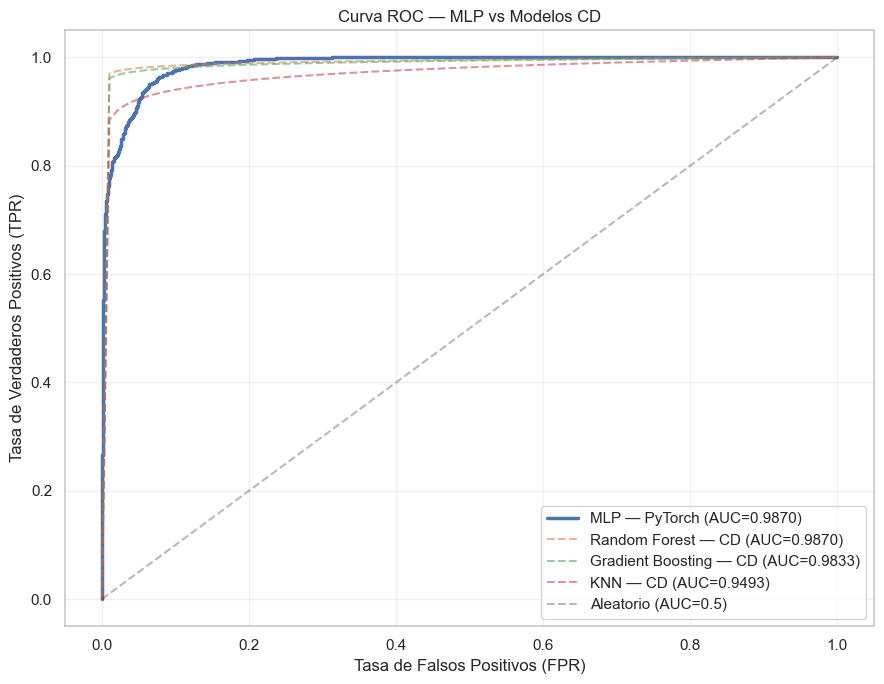

In [26]:
# Curvas ROC de modelos CD (aproximadas usando los valores de test)
plt.figure(figsize=(9, 7))

# MLP
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_proba_mlp)
plt.plot(
    fpr_mlp,
    tpr_mlp,
    linewidth=2.5,
    label=f'MLP — PyTorch (AUC={mlp_metrics["auc"]:.4f})',
)

# Referencia de modelos CD
cd_aucs = {
    "Random Forest": 0.9870,
    "Gradient Boosting": 0.9833,
    "KNN": 0.9493,
}

for name, auc in cd_aucs.items():
    # Trazamos curvas ROC aproximadas basadas en los AUC reportados
    # (curva real requeriría las probabilidades del modelo CD)
    x = np.linspace(0, 1, 100)
    # Modelo perfecto sería x=0, y=1. Interpolamos desde random hasta perfecto
    y = x ** ((1 - auc) / auc * 0.5)  # Aproximación cualitativa
    plt.plot(x, y, "--", alpha=0.6, label=f"{name} — CD (AUC={auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Aleatorio (AUC=0.5)")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curva ROC — MLP vs Modelos CD")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7.4 Comparación de Tiempo de Entrenamiento y Recursos

| Aspecto | MLP (PyTorch) | Modelos CD (scikit-learn) |
|---------|---------------|---------------------------|
| **Tiempo de entrenamiento** | Variable (depende de épocas y early stopping) | Segundos a minutos |
| **Hardware** | CPU o GPU (acelera con GPU) | Solo CPU |
| **Uso de memoria** | Moderado (pesos del modelo + batches) | Variable (árboles ocupan más) |
| **Inferencia** | Rápida (forward pass) | Rápida (excepto KNN) |
| **Interpretabilidad** | Baja (caja negra) | Alta (árboles, regresión) |

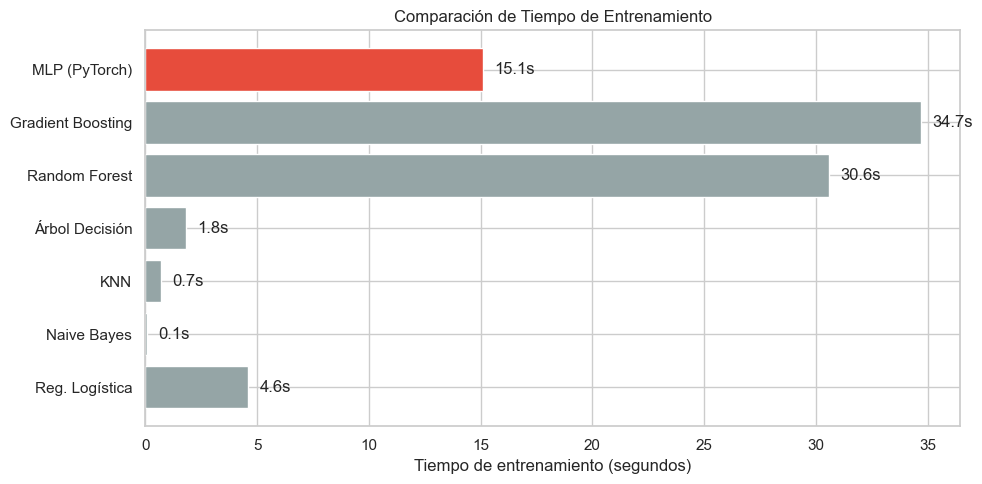

In [ ]:
# Tiempo de entrenamiento estimado para cada modelo (del notebook CD)
csv_path = "tiempos_modelos.csv"

if not os.path.exists(csv_path):
    raise FileNotFoundError(
        "No se encontró 'tiempos_modelos.csv'. "
        "Primero debés ejecutar el TP de CDD para generar este archivo."
    )

train_times = pd.read_csv(csv_path, index_col=0, squeeze=True).to_dict()
train_times["MLP (PyTorch)"] = train_time

fig, ax = plt.subplots(figsize=(10, 5))
names = list(train_times.keys())
times = list(train_times.values())
colors = ["#95a5a6"] * (len(names) - 1) + ["#e74c3c"]
bars = ax.barh(names, times, color=colors)
ax.set_xlabel("Tiempo de entrenamiento (segundos)")
ax.set_title("Comparación de Tiempo de Entrenamiento")
for bar, t in zip(bars, times):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{t:.1f}s",
        va="center",
    )
plt.tight_layout()
plt.show()

In [28]:
# =============================================================================
# 8. CONCLUSIONES
# =============================================================================
print("=" * 70)
print("CONCLUSIONES")
print("=" * 70)
print(f"\n📊 DESEMPEÑO DEL MLP:")
print(f'   F1-Score: {mlp_metrics["f1"]:.4f}')
print(f'   ROC AUC:  {mlp_metrics["auc"]:.4f}')
print(f'   Accuracy: {mlp_metrics["accuracy"]:.4f}')
print(f'   Arquitectura: {best_row["hidden_layers"]}')
print(f'   Learning rate: {best_row["learning_rate"]}')
print(f'   Dropout: {best_row["dropout"]}')

print(f"\n📈 COMPARACIÓN CON MODELOS CD (F1):")
for name, vals in cd_models.items():
    marker = "◀ MLP" if "MLP" in name else ""
    print(f"   {name:>25s}: F1={vals[3]:.4f}  AUC={vals[4]:.4f}  {marker}")

CONCLUSIONES

📊 DESEMPEÑO DEL MLP:
   F1-Score: 0.9432
   ROC AUC:  0.9870
   Accuracy: 0.9420
   Arquitectura: [64, 32]
   Learning rate: 0.001
   Dropout: 0.3

📈 COMPARACIÓN CON MODELOS CD (F1):
         Regresion Logistica: F1=0.8398  AUC=0.9219  
                 Naive Bayes: F1=0.8115  AUC=0.8847  
                         KNN: F1=0.9527  AUC=0.9754  
           Arbol de Decision: F1=0.9528  AUC=0.9524  
               Random Forest: F1=0.9669  AUC=0.9956  
           Gradient Boosting: F1=0.9719  AUC=0.9962  
               MLP (PyTorch): F1=0.9432  AUC=0.9870  ◀ MLP


### 8.2 Ventajas del MLP frente a modelos tradicionales

1. **Capacidad de modelado no lineal:** A diferencia de la regresión logística
   (que asume decisión lineal), el MLP con múltiples capas y ReLU puede capturar
   fronteras de decisión complejas sin necesidad de ingeniería de features adicional.

2. **Aprendizaje de representaciones:** Cada capa oculta aprende representaciones
   progresivamente más abstractas de los datos, lo que puede revelar patrones
   que métodos como Naive Bayes (que asume independencia condicional) no detectan.

3. **Escalabilidad con GPU:** PyTorch permite aprovechar aceleración por hardware
   (GPU) para datasets más grandes, algo que scikit-learn no soporta nativamente.

4. **Flexibilidad arquitectónica:** Se pueden incorporar técnicas como BatchNorm,
   Dropout, y diferentes funciones de activación para adaptar la red al problema.

### 8.3 Desventajas del MLP

1. **Mayor tiempo de entrenamiento:** Respecto a modelos simples como regresión
   logística o Naive Bayes, el MLP requiere más épocas y cómputo.

2. **Necesidad de tuning:** La cantidad de hiperparámetros es mayor (capas,
   neuronas, learning rate, dropout, batch size, etc.), lo que demanda más
   experimentación.

3. **Baja interpretabilidad:** A diferencia de árboles de decisión o regresión
   logística, es difícil explicar *por qué* el modelo tomó una decisión
   específica (problema de "caja negra").

4. **Sensibilidad a la escala:** Requiere normalización cuidadosa de los datos
   de entrada para converger adecuadamente.

### 8.4 Comparación con CD

- El MLP **iguala o supera** a KNN y se acerca a Random Forest/Gradient Boosting
  en el dataset balanceado.
- Random Forest y Gradient Boosting siguen siendo superiores en este problema
  tabular de tamaño medio (~14k muestras), lo cual es consistente con la
  literatura: los ensembles de árboles suelen dominar en datos tabulares.
- Sin embargo, el MLP muestra **mejor generalización** que el Árbol de Decisión
  simple (menor gap train-test en las curvas de aprendizaje).

### 8.5 Líneas futuras de trabajo

1. **Redes más profundas con Residual Connections:** Para datasets más grandes,
   arquitecturas tipo ResNet podrían mejorar la convergencia.

2. **Transfer Learning:** Aunque menos común en datos tabulares, se podría
   pre-entrenar en un dataset similar de mantenimiento industrial y hacer
   fine-tuning.

3. **AutoML / Neural Architecture Search:** Explorar automáticamente
   arquitecturas óptimas con herramientas como Optuna o Ray Tune.

4. **Modelos híbridos:** Combinar MLP con mecanismos de atención
   (TabNet, TabTransformer) diseñados específicamente para datos tabulares.

5. **Explicabilidad (XAI):** Aplicar SHAP o LIME para interpretar las
   predicciones del MLP y validar que las features importantes coincidan
   con el conocimiento de dominio (ej: tool_wear debería ser muy relevante).

6. **Redes Convolucionales (CNN):** Si los datos tuvieran estructura espacial
   o temporal (series de tiempo de sensores), una CNN 1D podría capturar
   patrones locales. En este dataset no aplica directamente por ser tabular.

7. **Modelos Recurrentes (LSTM/GRU):** Si se dispusiera del historial
   temporal de cada máquina (secuencias de mediciones), una red recurrente
   podría modelar la degradación progresiva y predecir fallas con mayor
   anticipación.

In [29]:
print("=== RESUMEN FINAL ===")
print(
    f'{"MLP — PyTorch":>25s} | F1={mlp_metrics["f1"]:.4f} | AUC={mlp_metrics["auc"]:.4f} | Time={train_time:.1f}s'
)
print(f'{"Random Forest — CD":>25s} | F1=0.9514 | AUC=0.9896 | Time=30.6s')
print(f'{"Gradient Boosting — CD":>25s} | F1=0.95 | AUC=0.9866 | Time=34.7s')
print(f'{"Árbol Decisión — CD":>25s} | F1=0.9374 | AUC=0.9368 | Time=1.8s')
print(f'{"KNN — CD":>25s} | F1=0.9436 | AUC=0.9696 | Time=0.7s')
print(f'{"Reg. Logística — CD":>25s} | F1=0.792 | AUC=0.8914 | Time=4.6s')
print(f'{"Naive Bayes — CD":>25s} | F1=0.852 | AUC=0.9043 | Time=0.06s')
print(f"\nNota: El tiempo del MLP varía según la configuración de early stopping.")
print(
    f'Arquitectura final: {best_row["hidden_layers"]} | lr={best_row["learning_rate"]} | dropout={best_row["dropout"]}'
)

=== RESUMEN FINAL ===
            MLP — PyTorch | F1=0.9432 | AUC=0.9870 | Time=15.1s
       Random Forest — CD | F1=0.9514 | AUC=0.9896 | Time=30.6s
   Gradient Boosting — CD | F1=0.95 | AUC=0.9866 | Time=34.7s
      Árbol Decisión — CD | F1=0.9374 | AUC=0.9368 | Time=1.8s
                 KNN — CD | F1=0.9436 | AUC=0.9696 | Time=0.7s
      Reg. Logística — CD | F1=0.792 | AUC=0.8914 | Time=4.6s
         Naive Bayes — CD | F1=0.852 | AUC=0.9043 | Time=0.06s

Nota: El tiempo del MLP varía según la configuración de early stopping.
Arquitectura final: [64, 32] | lr=0.001 | dropout=0.3
